# 01 · Data exploration

What data does Sharpee trade on, and where is it incomplete? Everything here is read from
`data/processed` (built by `scripts/download_data.py`) and the latest raw snapshot.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from sharpee.config import load_config, repo_path
from sharpee.data.download import latest_snapshot
from sharpee.data.preprocess import MarketData, eligibility
from sharpee.data.universe import membership_mask, to_yahoo
from sharpee.pipeline import eligibility_from_config

plt.rcParams.update({"figure.figsize": (9, 3.5), "axes.grid": True, "grid.alpha": 0.3})
cfg = load_config("data")
processed = repo_path(cfg["processed_dir"])
md = MarketData.load(processed)
log = json.loads((processed / "cleaning_log.json").read_text())
membership = pd.read_csv(latest_snapshot(repo_path(cfg["raw_dir"])) / "membership.csv",
                         parse_dates=["start_date", "end_date"])

print(f"{md.close.shape[1]} tickers with prices, {len(md.close)} trading days "
      f"({md.close.index[0].date()} to {md.close.index[-1].date()})")
print(f"{len(log['failed_downloads'])} historical members have no Yahoo data")

634 tickers with prices, 4529 trading days (2008-01-02 to 2025-12-31)
250 historical members have no Yahoo data


## 1. Survivorship: who is missing?

The index always has about 500 members. Comparing the historical membership list with the members
Yahoo could supply prices for shows where the data is incomplete.

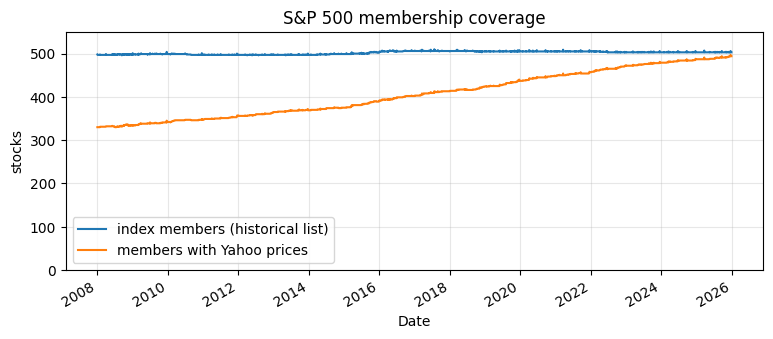

share of index members with price data at year end (%):
Date
2008-12-31    67.1
2009-12-31    68.5
2010-12-31    69.8
2011-12-31    71.8
2012-12-31    73.2
2013-12-31    74.2
2014-12-31    75.2
2015-12-31    77.7
2016-12-31    79.4
2017-12-31    81.6
2018-12-31    84.0
2019-12-31    86.5
2020-12-31    88.7
2021-12-31    90.5
2022-12-31    93.8
2023-12-31    95.2
2024-12-31    96.8
2025-12-31    98.2
Freq: YE-DEC


In [2]:
all_tickers = sorted({to_yahoo(t) for t in membership["ticker"]})
members = membership_mask(membership, md.close.index, all_tickers).sum(axis=1)
with_prices = md.member.sum(axis=1)

ax = members.plot(label="index members (historical list)")
with_prices.plot(ax=ax, label="members with Yahoo prices")
ax.set_ylim(0, 550)
ax.set_ylabel("stocks")
ax.set_title("S&P 500 membership coverage")
ax.legend()
plt.show()

coverage = (with_prices / members).resample("YE").last() * 100
print("share of index members with price data at year end (%):")
print(coverage.round(1).to_string())

Coverage rises from 67% of index members in 2008 to 98% in 2025. The missing names are the companies that later left the index (delisted, acquired or merged), and no free source has their prices. So the early universe is drawn mostly from survivors, which likely flatters results. This is disclosed rather than corrected.

## 2. The tradable universe

Eligibility is decided day by day from data up to that day: index member, at least 312 days of
history, price above $5. The universe is then the 150 most liquid of those stocks (20-day median
dollar volume).

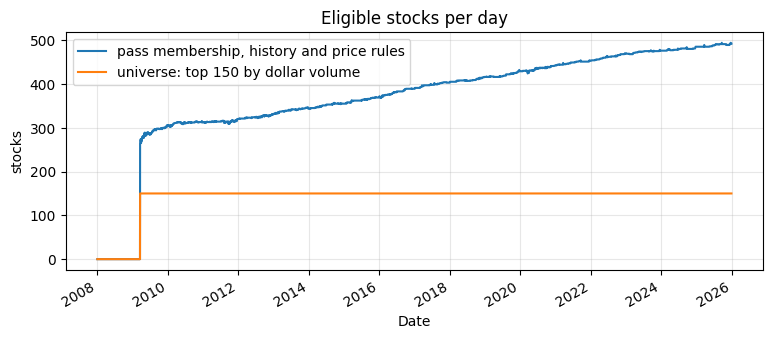

universe first reaches 150 names on 2009-03-20 (the 2008-2009 download is warm-up for the history requirement)


In [3]:
universe = eligibility_from_config(md, cfg)
passing = eligibility(md, universe_size=10_000, min_price=cfg["min_price"],
                      history_days=cfg["history_days"],
                      dollar_volume_window=cfg["dollar_volume_window"],
                      min_history_frac=cfg["min_history_frac"])

ax = passing.sum(axis=1).plot(label="pass membership, history and price rules")
universe.sum(axis=1).plot(ax=ax, label=f"universe: top {cfg['universe_size']} by dollar volume")
ax.set_ylabel("stocks")
ax.set_title("Eligible stocks per day")
ax.legend()
plt.show()

first_full = universe.sum(axis=1).ge(cfg["universe_size"]).idxmax()
print(f"universe first reaches {cfg['universe_size']} names on {first_full.date()} "
      f"(the 2008-2009 download is warm-up for the history requirement)")

## 3. Return distribution: fat tails

Daily returns of universe stocks (universe membership taken the day before each return, as a
strategy would see it), standardized and compared with a normal distribution.

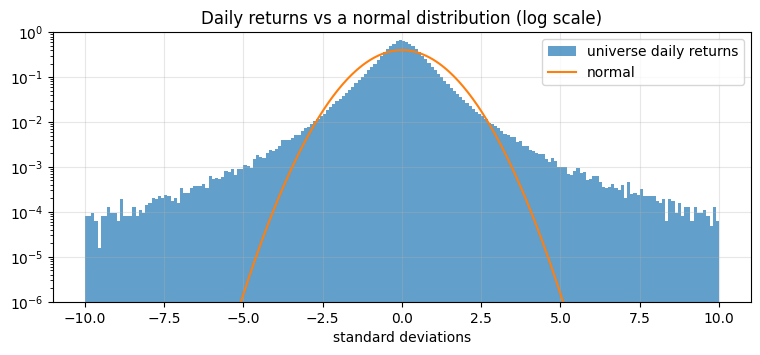

,value
observations,633299.000000
daily std,0.020570
skew,0.160826
excess kurtosis,19.590702
"share beyond 4 sd, actual",0.006820
"share beyond 4 sd, if normal",0.000063


In [4]:
in_universe = universe.shift(1, fill_value=False)
vals = md.returns.where(in_universe).to_numpy().ravel()
vals = vals[~np.isnan(vals)]
z = (vals - vals.mean()) / vals.std()

fig, ax = plt.subplots()
ax.hist(z, bins=200, range=(-10, 10), density=True, log=True, alpha=0.7, label="universe daily returns")
x = np.linspace(-10, 10, 400)
ax.plot(x, stats.norm.pdf(x), label="normal")
ax.set_ylim(1e-6, 1)
ax.set_xlabel("standard deviations")
ax.set_title("Daily returns vs a normal distribution (log scale)")
ax.legend()
plt.show()

pd.Series({
    "observations": len(vals),
    "daily std": vals.std(),
    "skew": stats.skew(vals),
    "excess kurtosis": stats.kurtosis(vals),
    "share beyond 4 sd, actual": (np.abs(z) > 4).mean(),
    "share beyond 4 sd, if normal": 2 * stats.norm.sf(4),
}).to_frame("value")

Returns are heavily fat-tailed: excess kurtosis is about 20, and 4-standard-deviation days are roughly 100 times more common than a normal distribution predicts. This is why the Phase 3 significance tests (Probabilistic and Deflated Sharpe Ratio) adjust for skewness and kurtosis instead of assuming normal returns.

## 4. Market regimes

SPY over the sample. The crises (2008, 2020) and the 2022 drawdown are the stress periods every
strategy has to live through.

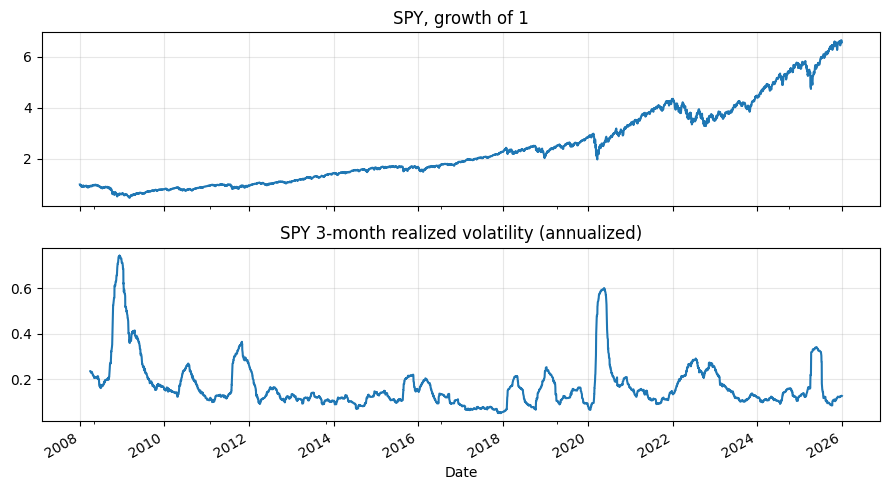

In [5]:
spy = md.market.dropna()
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
(1 + spy).cumprod().plot(ax=axes[0], title="SPY, growth of 1")
(spy.rolling(63).std() * np.sqrt(252)).plot(ax=axes[1], title="SPY 3-month realized volatility (annualized)")
fig.tight_layout()
plt.show()

## 5. Data-quality log

What `scripts/download_data.py` checked and recorded while cleaning. Large moves are kept, not
deleted, but logged. The question that matters is whether any bad prints reach the stocks a
strategy can actually trade.

In [6]:
print(f"duplicate dates: {len(log['duplicate_dates'])}   non-positive prices: {log['nonpositive_prices']}")
print(f"tickers with at least one daily move above 50%: {len(log['suspicious_jumps'])}")


def largest(moves, n=8):
    top = moves.loc[moves.abs().nlargest(n).index].round(3)
    return top.rename("return").to_frame().rename_axis(["date", "ticker"])


print("\nlargest daily moves in the raw data:")
display(largest(md.returns.stack().dropna()))
print("largest daily moves inside the tradable universe:")
display(largest(md.returns.where(in_universe).stack().dropna()))

duplicate dates: 0   non-positive prices: 0
tickers with at least one daily move above 50%: 53

largest daily moves in the raw data:


,,return
date,ticker,
2025-09-25,CPWR,21.000
2023-09-18,CPWR,15.667
2020-07-13,EQ,7.307
2025-10-31,CPWR,6.143
2025-10-29,CPWR,6.000
2025-12-19,CPWR,5.923
2025-06-10,CPWR,5.000
2014-03-07,EP,4.091


largest daily moves inside the tradable universe:


,,return
date,ticker,
2009-08-05,AIG,0.627
2019-01-14,PCG,-0.524
2020-03-09,OXY,-0.520
2013-04-09,FSLR,0.455
2020-11-04,BIIB,0.440
2018-06-04,NKTR,-0.418
2020-06-04,AAL,0.411
2014-06-24,VRTX,0.404


The raw data has a **ticker-reuse** problem. Some symbols of companies that left the index, such as
Compuware (`CPWR`) and El Paso (`EP`), now belong to unrelated securities on Yahoo. Their price
histories, even during the membership years, are not the original company's, which is why they show
impossible moves like +2,100% in a day. None of them ever enters the tradable universe: the $5 price
floor and the dollar-volume ranking screen them out. The largest moves inside the universe are real
events, such as AIG in 2009, PG&E's bankruptcy filing and the March 2020 oil crash.